# Phase 4 — Claude as Mission Coordinator (MCP)

This notebook demonstrates the MCP tool layer built in `src/mcp/`. A Claude agent acts
as a **strategic mission coordinator**: it receives a weather alert and decides how to
replan the mission to maximize coverage of high-priority strips before the storm arrives.

## The benchmark

Both runs operate under the **same storm deadline** — the same amount of work gets done.
The difference is *which strips* get prioritized:

| Run | Planning strategy | Strip selection within deadline |
|-----|-------------------|---------------------------------|
| A — Baseline | Makespan (balanced) | Round-robin, ignores priority |
| B — Weather-aware | Priority-weighted (MCP) | Highest priority strips first |

Run B should achieve meaningfully higher **priority-weighted coverage** despite doing
the same total amount of work.

## Architecture

```
Weather Feed ► Claude (Anthropic API + tool_use)
                      │
                  MCP Tools  ←─ src/mcp/tools.py
                      │
              Fleet Optimizer + Simulation
```

Claude is the only component that can observe the weather signal and decide how to respond.
The simulation itself knows nothing about weather.

## Setup

In [ ]:
import sys, importlib
sys.path.insert(0, '..')

import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm

import src.mcp.state_store as state_store
import src.mcp.weather as weather_feed
import src.mcp.tools as tools
importlib.reload(state_store)
importlib.reload(weather_feed)
importlib.reload(tools)

import anthropic

os.environ['ANTHROPIC_API_KEY'] = "YOUR_API_KEY_HERE"

%matplotlib inline

# --- Field / fleet config ---
USE_SYNTHETIC    = False
FIELD_IMAGE      = '../aerial_cropland_images/focused/stock1.jpg'
ORIENTATION_DEG  = 45
GRID_SIZE        = 32
N_DRONES         = 3
SECONDS_PER_CELL = 2.0

# --- Dock position ---
DOCK_POSITION = [0, GRID_SIZE - 1]   # top-right corner

# --- Mandatory compliance zones ---
N_MANDATORY = 6

# --- Storm timeline (fractions of makespan) ---
STORM_NOTICE_PCT   = 0.40
STORM_ARRIVAL_PCT  = 0.70

print(f'Field:           {FIELD_IMAGE}')
print(f'Orientation:     {ORIENTATION_DEG}°')
print(f'Grid:            {GRID_SIZE}×{GRID_SIZE}  |  Dock: {DOCK_POSITION}')
print(f'Mandatory zones: top {N_MANDATORY} strips by priority')
print(f'Storm notice:    {STORM_NOTICE_PCT:.0%} of makespan')
print(f'Storm arrival:   {STORM_ARRIVAL_PCT:.0%} of makespan  (pencils down)')

Field:           ../aerial_cropland_images/focused/stock1.jpg
Orientation:     45°
Grid:            32×32  |  Dock: [0, 31]
Mandatory zones: top 6 strips by priority
Storm notice:    40% of makespan
Storm arrival:   70% of makespan  (pencils down)


---
## Run A — Baseline: makespan plan, no weather awareness

Drones follow the balanced makespan plan in assignment order — no priority awareness,
no response to the incoming storm.

The storm timeline is derived from the plan's makespan so neither run finishes early:
- **Notice fires** at `STORM_NOTICE_PCT` of makespan → Run B replans; Run A ignores it
- **Storm arrives** at `STORM_ARRIVAL_PCT` of makespan → both runs stop ("pencils down")

In [2]:
state_store.clear()
weather_feed.disarm_alert()

r_a = tools.load_field(
    FIELD_IMAGE,
    target_size=GRID_SIZE,
    channel='green',
    orientation_deg=ORIENTATION_DEG,
)

run_id_a = r_a['run_id']
print(f"Run A  run_id={run_id_a}")
print(f"Strips: {r_a['strips']}")

Run A  run_id=ce4bdedd
Strips: {'count': 44, 'total_time_s': 3126.9, 'avg_priority': 0.528, 'max_priority': 0.836, 'min_priority': 0.231}


In [3]:
from src.mcp.field_events import generate_event_feed, events_to_dicts

plan_a = tools.create_plan(run_id_a, n_drones=N_DRONES, objective_mode='makespan')
makespan_s = plan_a['plan']['makespan_s']
print(f"Plan A: {plan_a['plan']['status']}, makespan = {makespan_s:.0f}s")

# Arm mandatory zones for Run A (tracked in metrics; A doesn't act on them)
mz_a = tools.arm_mandatory_zones(run_id_a, n_strips=N_MANDATORY)
print(f"\nMandatory zones: {mz_a['mandatory_count']} strips "
      f"(ids={mz_a['mandatory_strip_ids']}, avg priority={mz_a['avg_priority']})")

# Derive storm timeline from makespan
NOTICE_TIMESTEP = int(makespan_s / SECONDS_PER_CELL * STORM_NOTICE_PCT)
STORM_TIMESTEP  = int(makespan_s / SECONDS_PER_CELL * STORM_ARRIVAL_PCT)
NOTICE_MINUTES  = round(NOTICE_TIMESTEP * SECONDS_PER_CELL / 60, 1)
STORM_MINUTES   = round(STORM_TIMESTEP  * SECONDS_PER_CELL / 60, 1)

print(f"\nStorm timeline:")
print(f"  Notice fires at  t={NOTICE_TIMESTEP:>4}  ({NOTICE_MINUTES} min)")
print(f"  Storm arrives at t={STORM_TIMESTEP:>4}  ({STORM_MINUTES} min)")
print(f"  Response window:   {STORM_TIMESTEP - NOTICE_TIMESTEP} timesteps")

# Generate the field event feed — same events for both runs (same field)
raw_events = generate_event_feed(
    nrows=GRID_SIZE,
    ncols=GRID_SIZE,
    makespan_timesteps=STORM_TIMESTEP,
    n_events=4,
    start_pct=0.05,
    end_pct=0.90,
    seed=99,
)
FIELD_EVENTS = events_to_dicts(raw_events)
print(f"\nField event feed: {len(FIELD_EVENTS)} events")
for e in FIELD_EVENTS:
    print(f"  t={e['timestep']:>4}  [{e['event_type']:<16}]  ({e['row']},{e['col']})  "
          f"severity={e['severity']:.2f}  — {e['description'][:60]}")

Plan A: Optimal, makespan = 1042s

Mandatory zones: 6 strips (ids=[41, 40, 25, 39, 42, 38], avg priority=0.8)

Storm timeline:
  Notice fires at  t= 208  (6.9 min)
  Storm arrives at t= 364  (12.1 min)
  Response window:   156 timesteps

Field event feed: 4 events
  t= 120  [pest_sighting   ]  (5,23)  severity=0.70  — Field worker reports aphid cluster near (5, 23). Severity: 0
  t= 212  [sensor_alert    ]  (2,24)  severity=0.89  — Onboard sensor detects NDVI anomaly near (2, 24). Severity: 
  t= 224  [worker_report   ]  (16,18)  severity=0.98  — Ground crew flags fungal lesions near (16, 18). Severity: 0.
  t= 324  [sensor_alert    ]  (15,22)  severity=0.77  — Soil-moisture probe spike detected near (15, 22). Severity: 


In [4]:
# Run A stops when the storm hits — no weather awareness, just makespan order until pencils down
sim_a = tools.run_simulation(run_id_a, dock_position=DOCK_POSITION, max_timesteps=STORM_TIMESTEP)
metrics_a = tools.get_metrics(run_id_a)

print(f"Run A: stopped at t={sim_a['timesteps']} (storm at t={STORM_TIMESTEP})")
print(f"       coverage:          {metrics_a['coverage_pct']:.1f}%")
print(f"       priority_coverage: {metrics_a['priority_coverage']:.3f}")

Run A: stopped at t=364 (storm at t=364)
       coverage:          67.5%
       priority_coverage: 0.587


---
## Run B — Weather-Aware: Claude replans at the storm notice

Same field, same drones, **same makespan plan as Run A** — the two missions are
identical until `NOTICE_TIMESTEP`.

At the notice, Claude observes the alert and calls `run_weather_aware_simulation`,
which reorders each drone's remaining queue by priority and continues until the storm.

The benchmark question: how much more priority-weighted coverage does Run B achieve
by the time the storm arrives?

In [5]:
# Fresh session, same field and orientation as Run A
r_b = tools.load_field(
    FIELD_IMAGE,
    target_size=GRID_SIZE,
    channel='green',
    orientation_deg=ORIENTATION_DEG,
)
run_id_b = r_b['run_id']
print(f"Run B  run_id={run_id_b}")
print(f"Strips: {r_b['strips']}")

Run B  run_id=3f5f84dd
Strips: {'count': 44, 'total_time_s': 3126.9, 'avg_priority': 0.528, 'max_priority': 0.836, 'min_priority': 0.231}


In [6]:
# Identical starting plan as Run A
plan_b_initial = tools.create_plan(run_id_b, n_drones=N_DRONES, objective_mode='makespan')
print(f"Plan B: {plan_b_initial['plan']['status']}, "
      f"makespan={plan_b_initial['plan']['makespan_s']:.0f}s  (matches Run A ✓)")

# Same mandatory zones as Run A — Claude will learn about these via get_mandatory_strips()
mz_b = tools.arm_mandatory_zones(run_id_b, strip_ids=mz_a['mandatory_strip_ids'])
print(f"Mandatory zones: {mz_b['mandatory_count']} strips  (ids={mz_b['mandatory_strip_ids']})")

# Arm the field event feed — Claude polls this between simulation chunks
feed_b = tools.arm_event_feed(run_id_b, FIELD_EVENTS)
print(f"Event feed:      {feed_b['events_armed']} events  "
      f"(t={feed_b['first_event_at']}–{feed_b['last_event_at']})")

# Arm weather alert
alert = tools.arm_weather_alert(
    minutes_remaining=STORM_MINUTES,
    description=f'Thunderstorm cell approaching. Mission window closes in {STORM_MINUTES} min.',
)
print(f"Weather alert:   armed ({alert['minutes_remaining']} min remaining)")

Plan B: Optimal, makespan=1042s  (matches Run A ✓)
Mandatory zones: 6 strips  (ids=[41, 40, 25, 39, 42, 38])
Event feed:      4 events  (t=120–324)
Weather alert:   armed (12.1 min remaining)


In [7]:
CLAUDE_TOOLS = [
    {
        "name": "get_weather_alert",
        "description": "Check for active weather alerts. Returns alert status and minutes_remaining.",
        "input_schema": {"type": "object", "properties": {}, "required": []},
    },
    {
        "name": "get_mandatory_strips",
        "description": "Return the compliance / disease-priority strips that must be sprayed before the storm.",
        "input_schema": {
            "type": "object",
            "properties": {"run_id": {"type": "string"}},
            "required": ["run_id"],
        },
    },
    {
        "name": "run_simulation_until",
        "description": (
            "Run (or resume) the simulation until until_timestep. "
            "Call once for the first chunk (t=0 → NOTICE), then again after replanning (NOTICE → STORM)."
        ),
        "input_schema": {
            "type": "object",
            "properties": {
                "run_id":           {"type": "string"},
                "until_timestep":   {"type": "integer"},
                "dock_position":    {"type": "array", "items": {"type": "integer"}},
            },
            "required": ["run_id", "until_timestep", "dock_position"],
        },
    },
    {
        "name": "get_field_events",
        "description": (
            "Return field events (pest sightings, sensor alerts, worker reports) "
            "that fired in [since_timestep, until_timestep]. Call this after each chunk."
        ),
        "input_schema": {
            "type": "object",
            "properties": {
                "run_id":           {"type": "string"},
                "since_timestep":   {"type": "integer"},
                "until_timestep":   {"type": "integer"},
            },
            "required": ["run_id", "since_timestep", "until_timestep"],
        },
    },
    {
        "name": "find_strips_at",
        "description": "Find strips near a (row, col) coordinate. Use to map event locations to strip IDs.",
        "input_schema": {
            "type": "object",
            "properties": {
                "run_id":   {"type": "string"},
                "row":      {"type": "integer"},
                "col":      {"type": "integer"},
                "radius":   {"type": "integer", "description": "Manhattan radius, default 3"},
            },
            "required": ["run_id", "row", "col"],
        },
    },
    {
        "name": "update_planner_params",
        "description": (
            "Update optimization parameters before reoptimize(). "
            "Raise priority_weight (0–1) when field events flag critical zones. "
            "Add must_complete_strip_ids for strips that must be done before the storm."
        ),
        "input_schema": {
            "type": "object",
            "properties": {
                "run_id":                   {"type": "string"},
                "priority_weight":          {"type": "number"},
                "must_complete_strip_ids":  {"type": "array", "items": {"type": "integer"}},
                "exclude_strip_ids":        {"type": "array", "items": {"type": "integer"}},
            },
            "required": ["run_id"],
        },
    },
    {
        "name": "reoptimize",
        "description": (
            "Re-run the MILP optimizer on remaining strips using the current planner params. "
            "must_complete strips are front-loaded. Call run_simulation_until() after this."
        ),
        "input_schema": {
            "type": "object",
            "properties": {"run_id": {"type": "string"}},
            "required": ["run_id"],
        },
    },
]

def dispatch_tool(name, args):
    return getattr(tools, name)(**args)

print(f"Tools exposed to Claude ({len(CLAUDE_TOOLS)}):")
for t in CLAUDE_TOOLS:
    print(f"  {t['name']}")
print(f"\nMandatory strip IDs: {mz_b['mandatory_strip_ids']}")
print(f"Event feed:          {len(FIELD_EVENTS)} events (t={FIELD_EVENTS[0]['timestep']}–{FIELD_EVENTS[-1]['timestep']})")
print(f"Notice / storm:      t={NOTICE_TIMESTEP} / t={STORM_TIMESTEP}")

Tools exposed to Claude (7):
  get_weather_alert
  get_mandatory_strips
  run_simulation_until
  get_field_events
  find_strips_at
  update_planner_params
  reoptimize

Mandatory strip IDs: [41, 40, 25, 39, 42, 38]
Event feed:          4 events (t=120–324)
Notice / storm:      t=208 / t=364


In [8]:
client = anthropic.Anthropic()

scenario = f"""
You are a drone fleet mission coordinator. Run a 2-phase mission for session {run_id_b}.

PHASE 1: run_simulation_until until_timestep={NOTICE_TIMESTEP}, dock_position={DOCK_POSITION}
Then: get_field_events since=0 until={NOTICE_TIMESTEP}, get_mandatory_strips,
find_strips_at for each event, update_planner_params (raise priority_weight, add must_complete_strip_ids),
reoptimize.

PHASE 2: run_simulation_until until_timestep={STORM_TIMESTEP}, dock_position={DOCK_POSITION}

Then write 1-2 sentences: which events did you respond to and what changed in the plan.
""".strip()

messages      = [{"role": "user", "content": scenario}]
tool_call_log = []

print("=" * 65)
print("CLAUDE COORDINATOR — CHUNKED MISSION WITH LIVE FIELD INTELLIGENCE")
print("=" * 65)

while True:
    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=2048,
        tools=CLAUDE_TOOLS,
        messages=messages,
    )
    messages.append({"role": "assistant", "content": response.content})

    if response.stop_reason == "end_turn":
        for block in response.content:
            if hasattr(block, "text"):
                print("\nCLAUDE DECISION:")
                print(block.text)
        break

    if response.stop_reason == "tool_use":
        tool_results = []
        for block in response.content:
            if block.type == "tool_use":
                print(f"\n→ {block.name}({json.dumps(block.input)})")
                result = dispatch_tool(block.name, block.input)
                tool_call_log.append({"tool": block.name, "args": block.input, "result": result})
                print(f"  ← {json.dumps(result, indent=2)}")
                tool_results.append({
                    "type":        "tool_result",
                    "tool_use_id": block.id,
                    "content":     json.dumps(result),
                })
        messages.append({"role": "user", "content": tool_results})

print("\n" + "=" * 65)

CLAUDE COORDINATOR — CHUNKED MISSION WITH LIVE FIELD INTELLIGENCE

→ run_simulation_until({"run_id": "3f5f84dd", "until_timestep": 208, "dock_position": [0, 31]})
  ← {
  "run_id": "3f5f84dd",
  "ran_until_timestep": 208,
  "frames_this_chunk": 208,
  "total_history_length": 208,
  "coverage_pct": 26.0,
  "in_progress_cells": 103,
  "total_cells": 1024,
  "complete_cells": 266
}

→ get_mandatory_strips({"run_id": "3f5f84dd"})
  ← {
  "run_id": "3f5f84dd",
  "mandatory_count": 6,
  "complete": 0,
  "remaining": 6,
  "remaining_strip_ids": [
    38,
    39,
    40,
    41,
    42,
    25
  ],
  "strips": [
    {
      "id": 41,
      "priority": 0.836
    },
    {
      "id": 40,
      "priority": 0.826
    },
    {
      "id": 25,
      "priority": 0.805
    },
    {
      "id": 39,
      "priority": 0.788
    },
    {
      "id": 42,
      "priority": 0.786
    },
    {
      "id": 38,
      "priority": 0.761
    }
  ],
  "note": "6 of 6 mandatory zones still need spraying. Front-load 

In [9]:
# Simulation ran inside Claude's tool calls (two chunks). Pull metrics at storm arrival.
metrics_b = tools.get_metrics(run_id_b, deadline_timestep=STORM_TIMESTEP)
print("Run B metrics at storm arrival:")
for k, v in metrics_b.items():
    print(f"  {k:<28} {v}")

Run B metrics at storm arrival:
  coverage_pct                 56.25
  spray_coverage_pct           56.25
  grid_coverage_pct            56.25
  priority_coverage            0.515
  makespan                     364
  replan_count                 0
  failed_drone_count           0
  complete_cells               576
  failed_cells                 0
  total_cells                  1024
  total_spray_cells            1024
  efficiency                   0.002
  time_to_recovery             None
  coverage_at_failure          None
  mandatory_complete           6
  mandatory_total              6
  mandatory_coverage_pct       100.0


---
## Benchmark: Run A vs Run B

Both runs used the **same makespan plan** and stopped at the **same storm timestep**.
The only difference: at `NOTICE_TIMESTEP`, Run B's queues were reordered by priority.

The metric that matters: **priority_coverage** — how much of the high-value crop area
was treated before the storm shut the mission down.

In [10]:
_display = {
    "coverage_pct":           "Overall coverage (%)",
    "priority_coverage":      "Urgency-weighted coverage",   # strip.priority = veg density
    "mandatory_coverage_pct": "Mandatory zone coverage (%) ★",
    "makespan":               "Makespan (s)",
}

print(f"Pencils down at storm arrival  t={STORM_TIMESTEP}  ({STORM_MINUTES} min)\n")
print(f"{'Metric':<35} {'Run A':>12} {'Run B':>12} {'Δ':>9}")
print("-" * 72)
for key, label in _display.items():
    va = metrics_a.get(key, float("nan"))
    vb = metrics_b.get(key, float("nan"))
    delta = vb - va
    sign  = "+" if delta >= 0 else ""
    print(f"  {label:<33} {va:>12.1f} {vb:>12.1f} {sign}{delta:>8.1f}")

print(f"\n  ★  {N_MANDATORY} compliance strips designated before mission start.")
print(     "     Run A had no knowledge of them. Run B received them via MCP.")
print(f"\n  Note: 'urgency' = vegetation density (spray need), not task priority.")

Pencils down at storm arrival  t=364  (12.1 min)

Metric                                     Run A        Run B         Δ
------------------------------------------------------------------------
  Overall coverage (%)                      67.5         56.2    -11.2
  Urgency-weighted coverage                  0.6          0.5     -0.1
  Mandatory zone coverage (%) ★             16.7        100.0 +    83.3
  Makespan (s)                             364.0        364.0 +     0.0

  ★  6 compliance strips designated before mission start.
     Run A had no knowledge of them. Run B received them via MCP.

  Note: 'urgency' = vegetation density (spray need), not task priority.


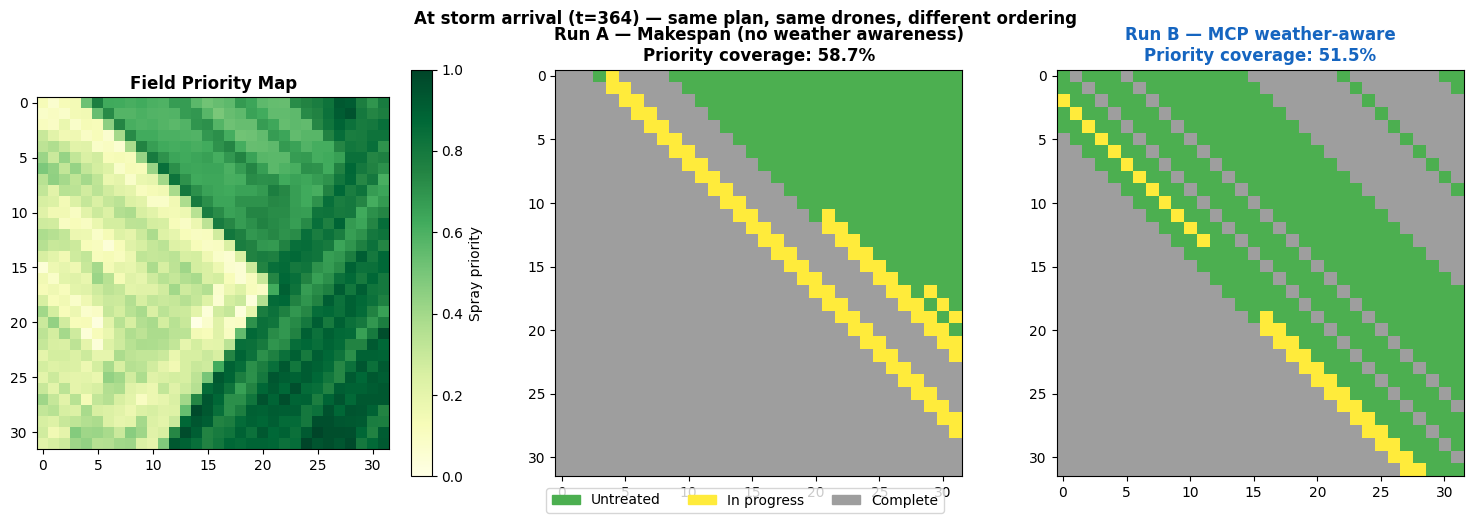

In [11]:
session_a = state_store.get_run(run_id_a)
session_b = state_store.get_run(run_id_b)

# Both histories already stop at the storm — use the final frame
grid_a = np.array(session_a['state_history'][-1]['grid'])
grid_b = np.array(session_b['state_history'][-1]['grid'])
priority_grid = np.array(session_a['grid'])

cmap = ListedColormap(['#4caf50', '#ffeb3b', '#9e9e9e', '#f44336'])
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

im0 = axes[0].imshow(priority_grid, cmap='YlGn', vmin=0, vmax=1)
plt.colorbar(im0, ax=axes[0], label='Spray priority')
axes[0].set_title('Field Priority Map', fontweight='bold')

cov_a = metrics_a.get('priority_coverage', 0)
axes[1].imshow(grid_a, cmap=cmap, norm=norm)
axes[1].set_title(
    f'Run A — Makespan (no weather awareness)\nPriority coverage: {cov_a:.1%}',
    fontweight='bold'
)

cov_b = metrics_b.get('priority_coverage', 0)
axes[2].imshow(grid_b, cmap=cmap, norm=norm)
axes[2].set_title(
    f'Run B — MCP weather-aware\nPriority coverage: {cov_b:.1%}',
    fontweight='bold', color='#1565c0'
)

legend_patches = [
    mpatches.Patch(color='#4caf50', label='Untreated'),
    mpatches.Patch(color='#ffeb3b', label='In progress'),
    mpatches.Patch(color='#9e9e9e', label='Complete'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.04))
plt.suptitle(
    f'At storm arrival (t={STORM_TIMESTEP}) — same plan, same drones, different ordering',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.show()

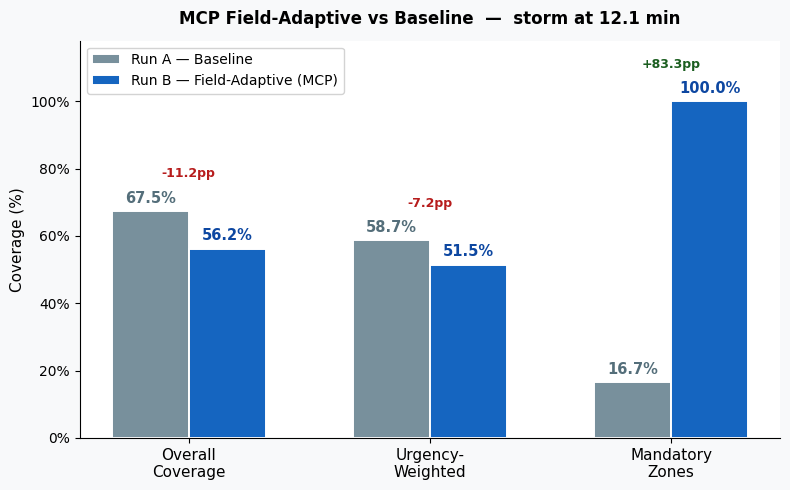

In [12]:
categories = ["Overall\nCoverage", "Urgency-\nWeighted", "Mandatory\nZones"]
keys       = ["coverage_pct", "priority_coverage", "mandatory_coverage_pct"]

# Normalise to 0-100 for uniform axis
def _to_pct(metrics, key):
    v = metrics.get(key, 0.0)
    return v * 100 if key == "priority_coverage" else v   # priority_coverage is 0-1

vals_a = [_to_pct(metrics_a, k) for k in keys]
vals_b = [_to_pct(metrics_b, k) for k in keys]

x     = np.arange(len(categories))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor("#f8f9fa")

bars_a = ax.bar(x - width / 2, vals_a, width,
                label="Run A — Baseline", color="#78909c",
                edgecolor="white", linewidth=1.4)
bars_b = ax.bar(x + width / 2, vals_b, width,
                label="Run B — Field-Adaptive (MCP)", color="#1565c0",
                edgecolor="white", linewidth=1.4)

for bars, vals, col in [(bars_a, vals_a, "#546e7a"), (bars_b, vals_b, "#0d47a1")]:
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 1.5,
                f"{val:.1f}%",
                ha="center", va="bottom",
                fontsize=10.5, fontweight="bold", color=col)

# Lift annotations between bar pairs
for i, (va, vb) in enumerate(zip(vals_a, vals_b)):
    lift = vb - va
    sign = "+" if lift >= 0 else ""
    color = "#1b5e20" if lift > 0 else "#b71c1c"
    ax.text(i, max(va, vb) + 9, f"{sign}{lift:.1f}pp",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold", color=color)

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 118)
ax.set_ylabel("Coverage (%)", fontsize=11)
ax.set_title(
    f"MCP Field-Adaptive vs Baseline  —  storm at {STORM_MINUTES} min",
    fontsize=12, fontweight="bold", pad=12,
)
ax.legend(fontsize=10, framealpha=0.85)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))

plt.tight_layout()
plt.savefig("../results/mcp_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Storm Warning GIF

Side-by-side animation: both runs play simultaneously. A red storm warning banner fires
partway through, and Run B shows the MCP-engaged annotation.

c:\Users\cunnk\Desktop\drones\notebooks\..\src\viz\weather_demo.py:251: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  c = plt.Circle((0, 0), marker_r, color=col, zorder=9,
c:\Users\cunnk\Desktop\drones\notebooks\..\src\viz\weather_demo.py:480: UserWarning: Glyph 128225 (\N{SATELLITE ANTENNA}) missing from font(s) DejaVu Sans Mono.
  anim.save(save_path, writer="pillow", fps=fps,


Saved: ../results/mcp_demo.gif
Urgency-weighted coverage — A: 58.7%  B: 51.5%  (lift -7.2%)
Mandatory zone coverage   — A: 16.7%  B: 100.0%  (lift +83.3pp)


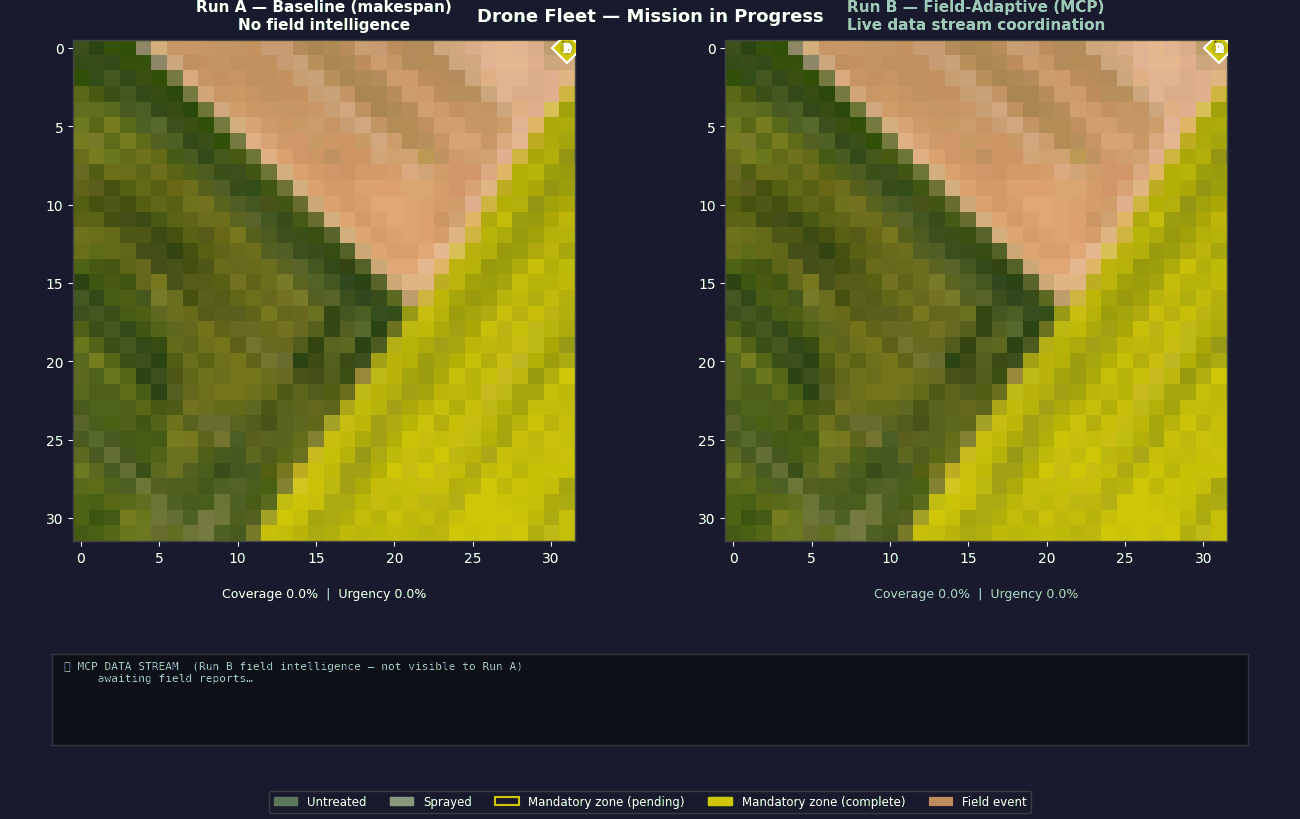

In [13]:
import importlib
import src.viz.weather_demo as wd
importlib.reload(wd)
from src.viz.weather_demo import create_weather_demo_gif
from src.field.ingest import load_image_as_array

bg = load_image_as_array(FIELD_IMAGE, target_size=GRID_SIZE)

gif_path = create_weather_demo_gif(
    session_a        = state_store.get_run(run_id_a),
    session_b        = state_store.get_run(run_id_b),
    metrics_a        = metrics_a,
    metrics_b        = metrics_b,
    notice_timestep  = NOTICE_TIMESTEP,   # alert fires here → countdown + mandatory zones revealed on Run B
    storm_timestep   = STORM_TIMESTEP,    # simulation already ends here; used for countdown math
    save_path        = '../results/mcp_demo.gif',
    fps              = 7,
    frame_step       = 3,
    background_image = bg,
    field_events     = FIELD_EVENTS,
)

from IPython.display import Image
Image(gif_path)

---
## Tool Call Trace

In [14]:
print(f"Claude made {len(tool_call_log)} tool call(s):\n")
for i, call in enumerate(tool_call_log, 1):
    print(f"[{i}] {call['tool']}")
    if call['args']:
        print(f"     args:   {json.dumps(call['args'])}")
    result_preview = {k: v for k, v in call['result'].items() if not isinstance(v, list)}
    print(f"     result: {json.dumps(result_preview)}")
    print()

Claude made 7 tool call(s):

[1] run_simulation_until
     args:   {"run_id": "3f5f84dd", "until_timestep": 208, "dock_position": [0, 31]}
     result: {"run_id": "3f5f84dd", "ran_until_timestep": 208, "frames_this_chunk": 208, "total_history_length": 208, "coverage_pct": 26.0, "in_progress_cells": 103, "total_cells": 1024, "complete_cells": 266}

[2] get_mandatory_strips
     args:   {"run_id": "3f5f84dd"}
     result: {"run_id": "3f5f84dd", "mandatory_count": 6, "complete": 0, "remaining": 6, "note": "6 of 6 mandatory zones still need spraying. Front-load these in the replan to ensure compliance before storm arrival."}

[3] get_field_events
     args:   {"run_id": "3f5f84dd", "since_timestep": 0, "until_timestep": 208}
     result: {"run_id": "3f5f84dd", "event_count": 1, "note": "1 events in t=[0, 208]. For each event: call find_strips_at(row, col) to identify affected strips, then update_planner_params() and reoptimize()."}

[4] find_strips_at
     args:   {"run_id": "3f5f84dd", "r

---
## MCP Server (Claude Code Integration)

The same tools run as an MCP server in `src/mcp/server.py`:

```bash
python -m src.mcp.server
```

Add to `.claude/settings.json`:
```json
{
  "mcpServers": {
    "drone-fleet": {
      "command": "python",
      "args": ["-m", "src.mcp.server"],
      "cwd": "/path/to/drones"
    }
  }
}
```

### Fallback behavior
If the coordinator link drops, each drone falls back to the three-tier planner's heuristic mode.
Never optimal, always feasible:
```
Coordinator LLM → degraded MILP → greedy heuristic
                       ↑ link drop
```

In [15]:
# Verify server imports and tool registration
try:
    from src.mcp.server import mcp
    tool_names = [t.name for t in mcp._tool_manager.list_tools()]
    print(f"MCP server OK — {len(tool_names)} tools:")
    for name in tool_names:
        print(f"  \u2022 {name}")
except Exception as e:
    from src.mcp import server as _srv  # noqa
    print(f"Server imports OK (tool listing API varies by mcp version: {e})")

MCP server OK — 9 tools:
  • load_synthetic_field
  • load_field
  • create_plan
  • run_simulation
  • get_state
  • get_metrics
  • get_weather_alert
  • arm_weather_alert
  • replan_with_deadline
